Inputs shape: (17, 2)
Outputs shape: (17,)
First 20 rows of raw data:
    number-1  number-2  log-likelyhood-score  source
9   0.702637  0.926564              0.611205    file
13  0.691873  0.263356              0.596081  week-4
0   0.665800  0.123969              0.538996    file
12  0.722766  0.839711              0.533827  week-3
1   0.877791  0.778628              0.420586    file
3   0.845275  0.711120              0.293993    file
6   0.438166  0.685018              0.244619    file
4   0.454647  0.290455              0.214965    file
11  0.616162  1.000000              0.180119  week-2
10  0.818182  0.939394              0.051646  week-1
16  1.077791  0.617990              0.041708  week-7
7   0.341750  0.028698              0.038749    file
5   0.577713  0.771973              0.023106    file
15  0.977791  0.261960              0.021321  week-6
14  0.790304  0.104833              0.016862  week-5
8   0.338648  0.213867             -0.013858    file
2   0.142699  0.349005       

/Users/ajay.amrite/Documents/AI Course/Capstone/Black-Box functions/data/BaseDataHandler.py:134: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_copy = pd.concat([df, new_df], ignore_index=True)


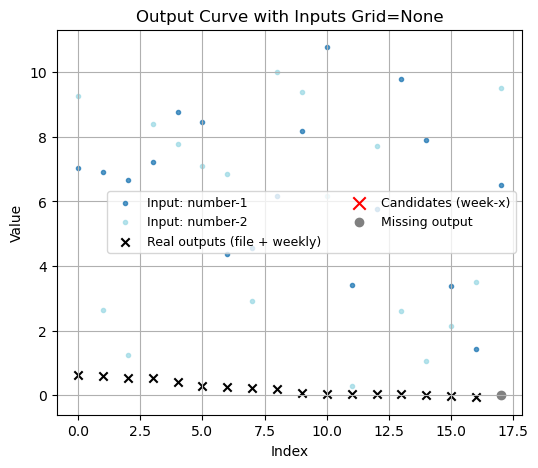

Saved LLM candidates to: results/run_2025-12-19 03-20-55/df_llm_candidates.csv

Pipeline finished.
Pipeline finished. Results keys: ['llm']


In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (12, 8)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh)

print("Pipeline finished. Results keys:", list(results.keys()))